# Project Python Foundations: FoodHub Data Analysis

### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost_of_the_order: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [ ]:
!pip install h5py
!pip install typing-extensions
!pip install wheel

In [41]:
# Installing the libraries with the specified version.
!pip install numpy==1.25.2 pandas==1.5.3 matplotlib==3.7.1 seaborn==0.13.1 -q --user

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [ ]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

### Understanding the structure of the data

In [ ]:
# uncomment and run the following lines for Google Colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Write your code here to read the data
data = pd.read_csv('/content/drive/MyDrive/Python Course/foodhub_order.csv')

In [ ]:
# Write your code here to view the first 5 rows
data.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [ ]:
# Write your code here
data.shape

(1898, 9)

#### Observations:
There are 1898 rows and 9 columns present in the dataset

### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [ ]:
# Write your code here
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations:
There are 5 numerical columns and 4 object type columns

### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [ ]:
# Write your code here
#checking if there are any missing values in data
data.isnull().sum()

order_id                 0
customer_id              0
restaurant_name          0
cuisine_type             0
cost_of_the_order        0
day_of_the_week          0
rating                   0
food_preparation_time    0
delivery_time            0
dtype: int64

#### Observations:
There are no missing values in above data


### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [ ]:
# Write your code here
data.describe().T

,count,mean,std,min,25%,50%,75%,max
order_id,1898.0,1.477496e+06,548.049724,1476547.00,1477021.25,1477495.50,1.477970e+06,1478444.00
customer_id,1898.0,1.711685e+05,113698.139743,1311.00,77787.75,128600.00,2.705250e+05,405334.00
cost_of_the_order,1898.0,1.649885e+01,7.483812,4.47,12.08,14.14,2.229750e+01,35.41
food_preparation_time,1898.0,2.737197e+01,4.632481,20.00,23.00,27.00,3.100000e+01,35.00
delivery_time,1898.0,2.416175e+01,4.972637,15.00,20.00,25.00,2.800000e+01,33.00


#### Observations:
Minimum time to prepare food is 20 minutes
Maximum time to prepare food is 35 minutes
Average time to prepare food is 3 mins

### **Question 5:** How many orders are not rated? [1 mark]

In [ ]:
# Write the code here
#filtering orders which are not rated
data.value_counts(data['rating']=='Not given')

rating
False    1162
True      736
Name: count, dtype: int64

#### Observations:
Out of 1898 orders 736 orders have not been rated

### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

In [ ]:
# Write the code here

#Number of unique restaurants
data['restaurant_name'].nunique()



178

In [ ]:
data['cuisine_type'].nunique() #no of unique cuisines

14

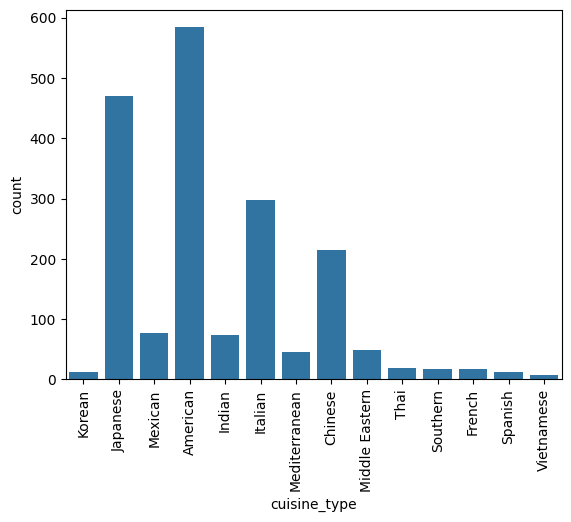

In [ ]:

sns.countplot(data = data, x = 'cuisine_type') #countplot for cuisine type
plt.xticks(rotation=90)
plt.show()



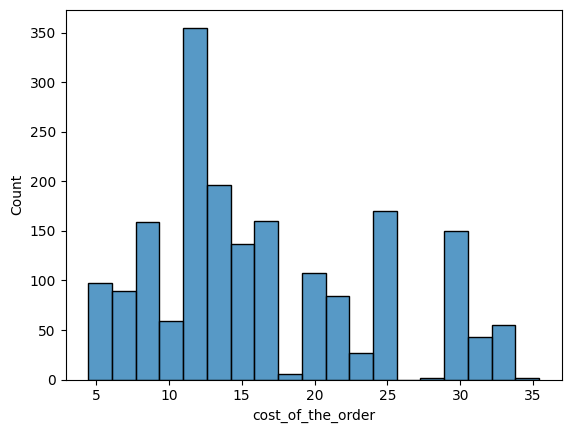

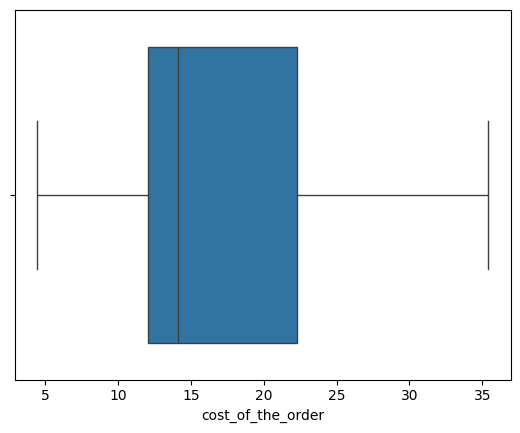

In [ ]:
#Cost of Order
sns.histplot(data=data,x='cost_of_the_order') ## Histogram for the cost of order
plt.show()
sns.boxplot(data=data,x='cost_of_the_order') ## Boxplot for the cost of order
plt.show()

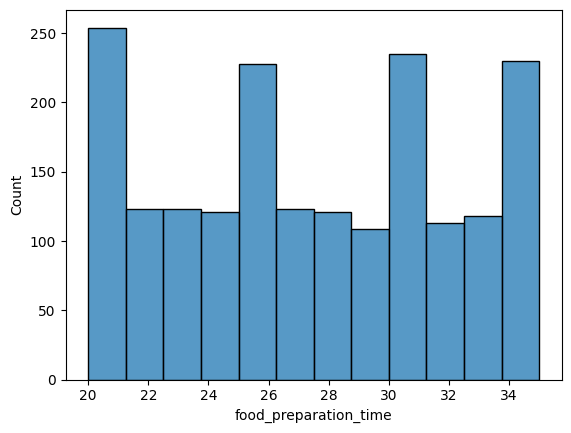

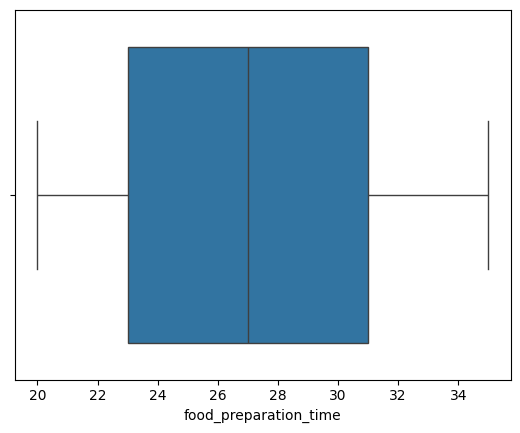

In [ ]:
#food preparation time
sns.histplot(data=data,x='food_preparation_time') ## Histogram for the food preparation time
plt.show()
sns.boxplot(data=data,x='food_preparation_time') ## Boxplot for the food preparation time
plt.show()



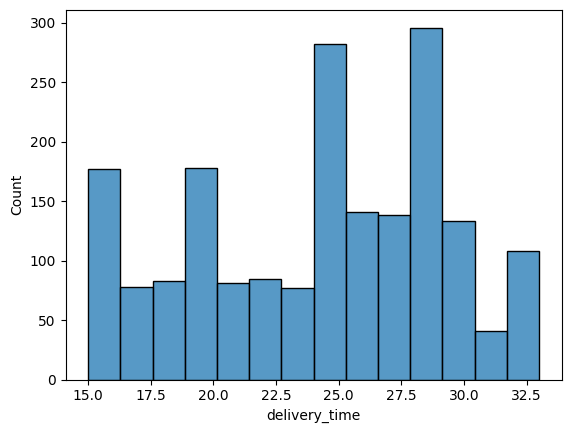

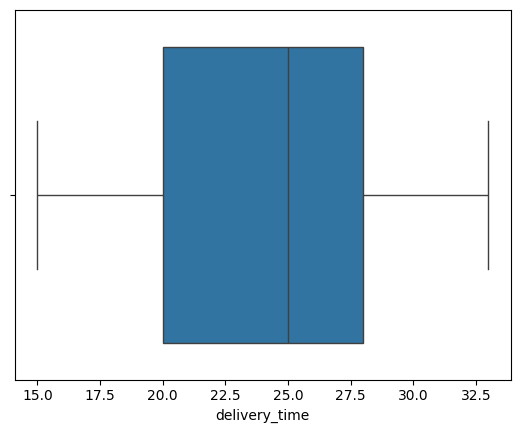

In [ ]:
#Delivery time
sns.histplot(data=data,x='delivery_time') ## Histogram for the delivery time
plt.show()
sns.boxplot(data=data,x='delivery_time') ## Boxplot for the delivery time
plt.show()

### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [ ]:
#Filtering based on the number of orders
data['restaurant_name'].value_counts().head(5)

restaurant_name
Shake Shack                  219
The Meatball Shop            132
Blue Ribbon Sushi            119
Blue Ribbon Fried Chicken     96
Parm                          68
Name: count, dtype: int64

#### Observations:
American,Italian,Japanese cuisines served by these restaurants have got the highest number of orders.

### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [ ]:
# Write the code here
#filtering data based upon weekend
data_Wknd = data[data['day_of_the_week'] == 'Weekend']
data_Wknd['cuisine_type'].value_counts().head(1)

cuisine_type
American    415
Name: count, dtype: int64

#### Observations:
In the most of restaurants we can observe that American cuisine is the most popular cuisine on weekends

### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [ ]:
# Write the code here
#filtering data based upon cost of order
data_greater_20=data[data['cost_of_the_order']>20]
no_of_orders =data_greater_20.shape[0]
#calculating percentage
Percentage_of_Order=(no_of_orders / data.shape[0]) * 100
print("Percentage of orders costing more than 20 dollars:", round(Percentage_of_Order, 2), '%')

Percentage of orders costing more than 20 dollars: 29.24 %


#### Observations:


### **Question 10**: What is the mean order delivery time? [1 mark]

In [ ]:
# Write the code here
#finding the mean
mean_orderdeliverytime = data['delivery_time'].mean()
print("The mean order delivery time is:", round(mean_orderdeliverytime, 2), '%')


The mean order delivery time is: 24.16 %


#### Observations:


### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [ ]:
# Write the code here
top_3_customers = data['customer_id'].value_counts().head(3)
print("Top 3 customers eligible for discount are : \n" ,top_3_customers)

Top 3 customers eligible for discount are : 
 customer_id
52832    13
47440    10
83287     9
Name: count, dtype: int64


#### Observations:


### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


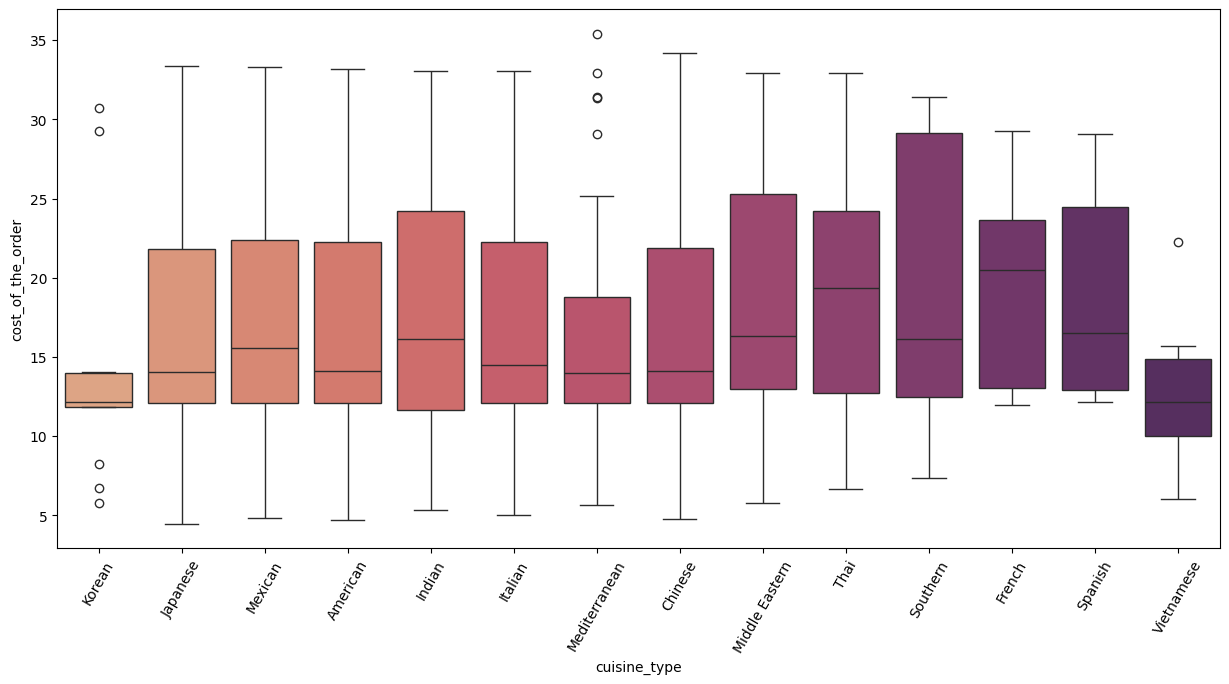

In [ ]:
# cuisinetype Vs Cost of order
plt.figure(figsize=(15,7))
sns.boxplot(x = "cuisine_type", y = "cost_of_the_order", data = data, palette = 'flare', hue = "cuisine_type")
plt.xticks(rotation = 60)
plt.show()

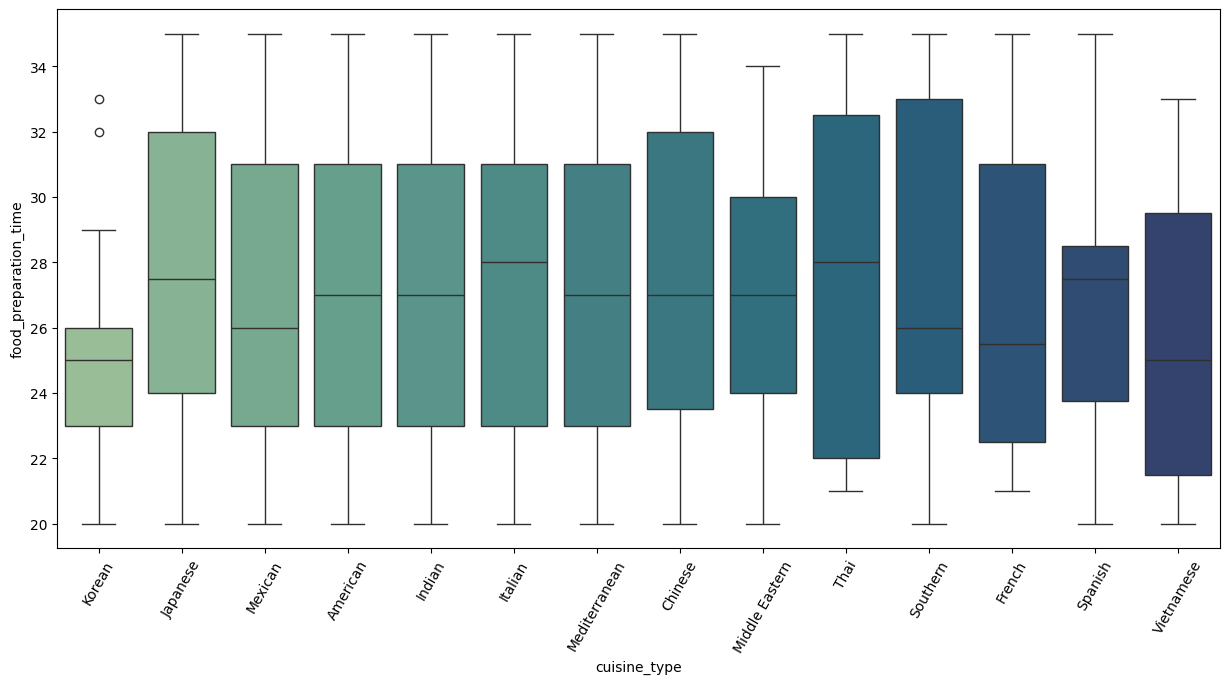

In [ ]:
# food preparation time vs cuisine type
plt.figure(figsize=(15,7))
sns.boxplot(x = "cuisine_type", y = "food_preparation_time", data = data, palette = 'crest', hue = "cuisine_type")
plt.xticks(rotation = 60)
plt.show()


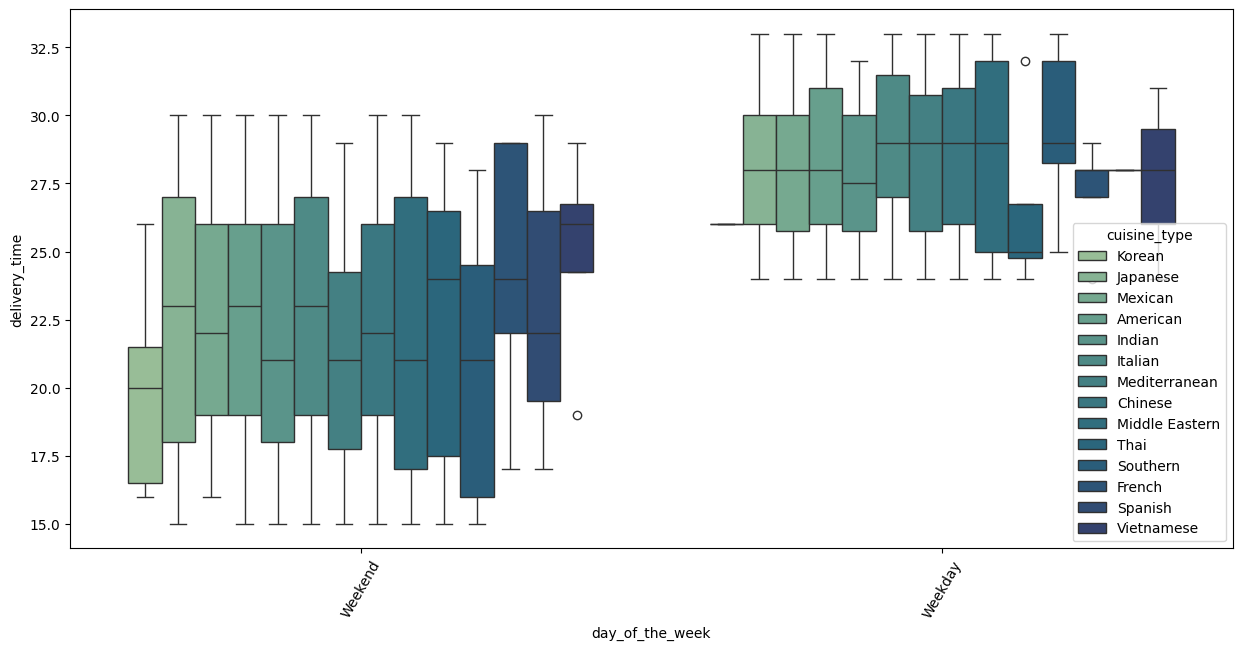

In [ ]:
# Day of week vs delivery time
plt.figure(figsize=(15,7))
sns.boxplot(x = "day_of_the_week", y = "delivery_time", data = data, palette = 'crest', hue = "cuisine_type")
plt.xticks(rotation = 60)
plt.show()

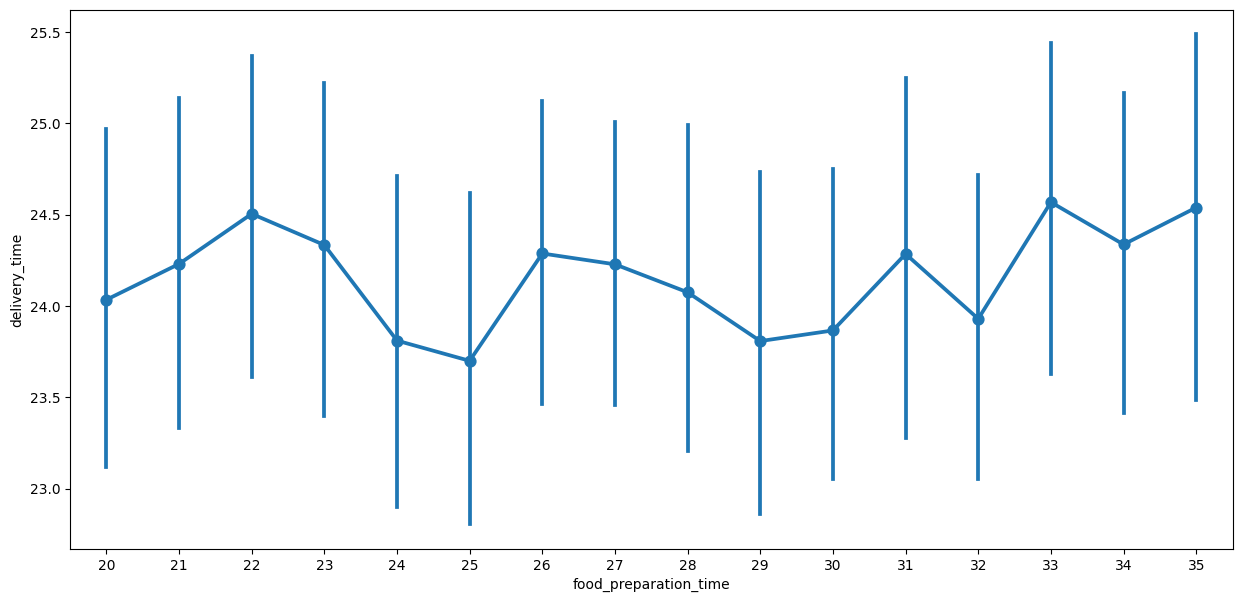

In [ ]:
#Food Preparation Time Vs Delivery time
plt.figure(figsize=(15, 7))
sns.pointplot(data=data,x='food_preparation_time',y='delivery_time')
plt.show()

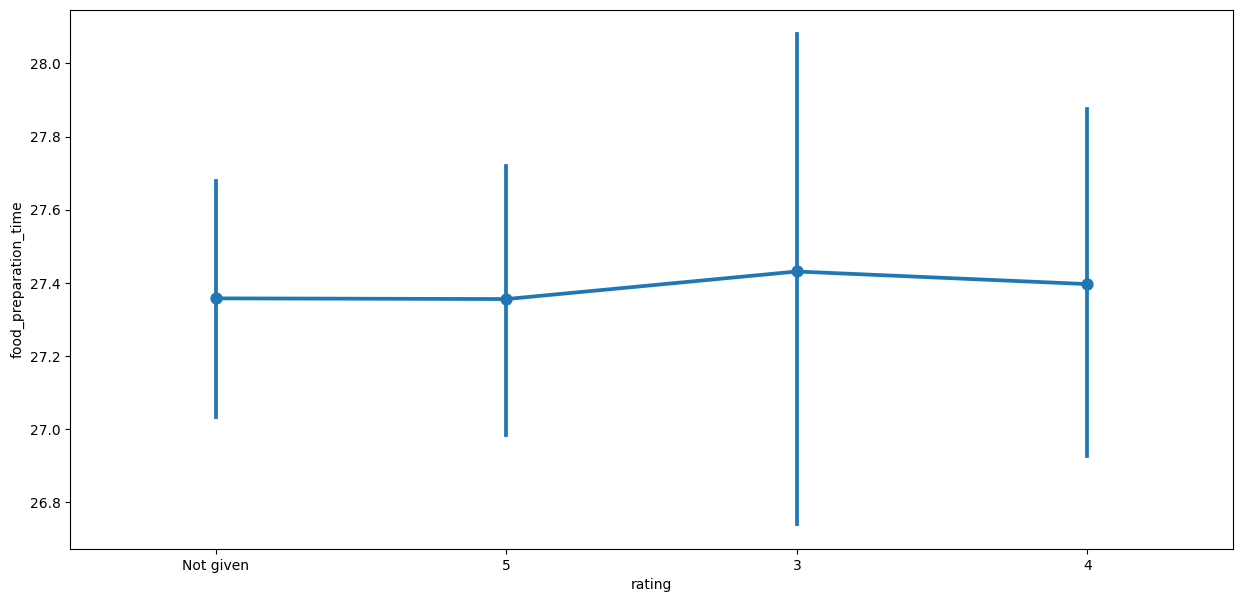

In [ ]:
#Rating vs Food preparation time

plt.figure(figsize=(15, 7))
sns.pointplot(data=data, x='rating',y='food_preparation_time')
plt.show()

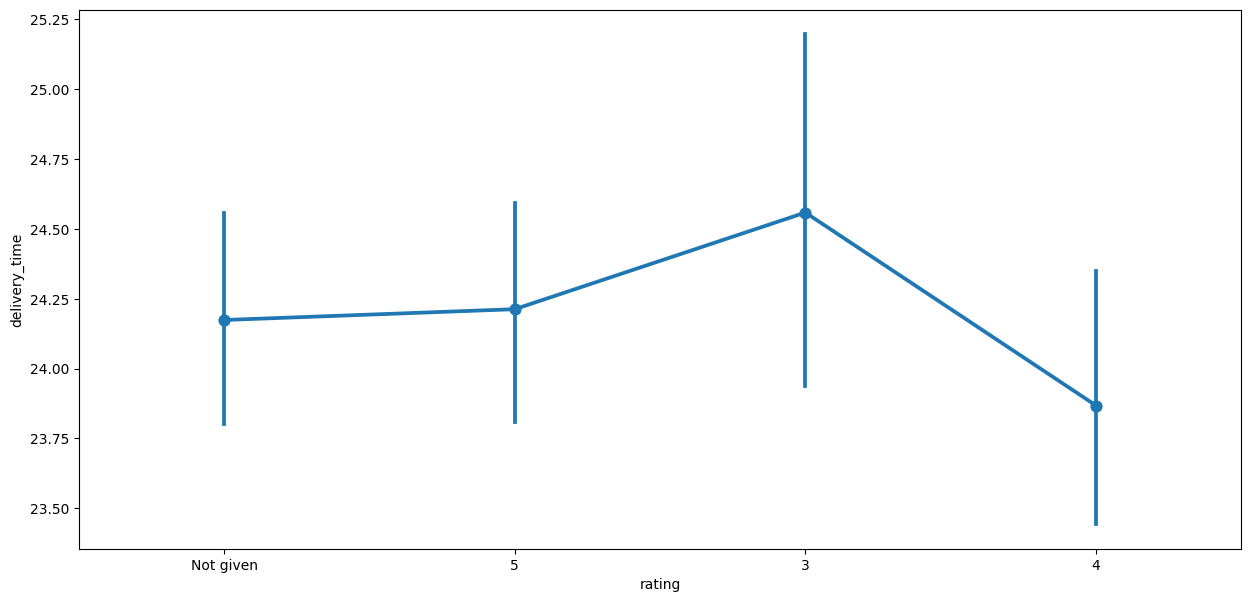

In [ ]:
#Rating Vs delivery_time

plt.figure(figsize=(15, 7))
sns.pointplot(data=data,x='rating',y='delivery_time')
plt.show()

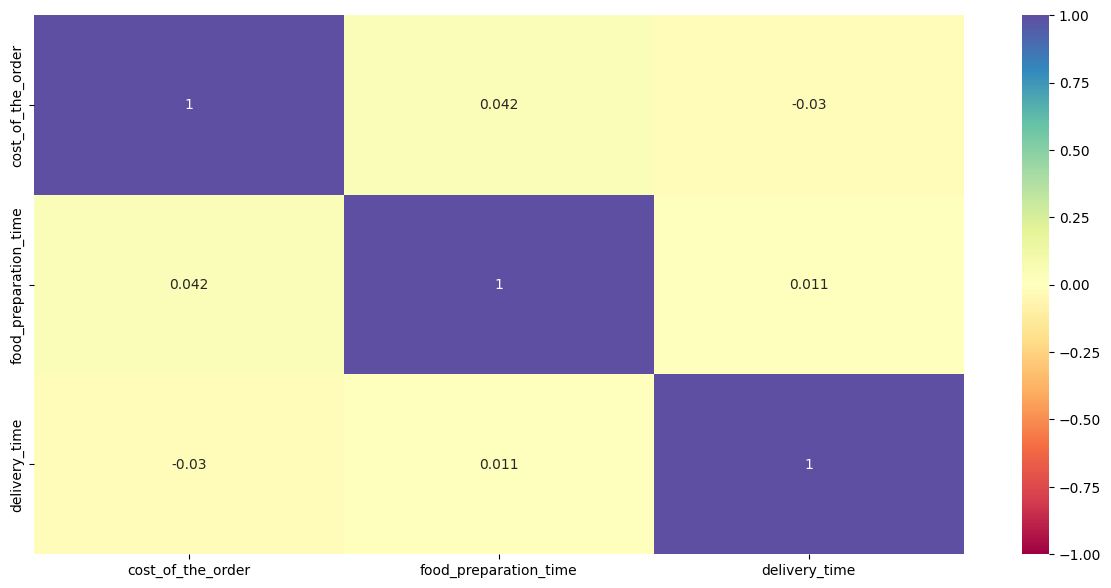

In [ ]:
col_list = ['cost_of_the_order', 'food_preparation_time', 'delivery_time']
plt.figure(figsize=(15, 7))
sns.heatmap(data[col_list].corr(), annot=True, vmin=-1, vmax=1,  cmap="Spectral") #correleation
plt.show()

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [ ]:

# Filter the rated restaurants
data_rated = data[data['rating'] != 'Not given'].copy()

data_rated['rating'] = data_rated['rating'].astype('int')

# creating a dataframe that contains the restaurant names with their rating counts
data_rating_count = data_rated.groupby(['restaurant_name'])['rating'].count().sort_values(ascending = False).reset_index()
data_rating_count.head()

rest_names = data_rating_count[data_rating_count['rating'] > 50]['restaurant_name']

data_mean_4 = data_rated[data_rated['restaurant_name'].isin(rest_names)].copy()

# grouping the restaurant names with their ratings and find the mean rating of each restaurant
data_mean_4_rating = data_mean_4.groupby(['restaurant_name'])['rating'].mean().sort_values(ascending = False).reset_index().dropna()

# filter for average rating greater than 4
data_avg_rating_greater_than_4 = data_mean_4_rating[data_mean_4_rating['rating'] > 4].sort_values(by='rating', ascending=False).reset_index(drop=True)

data_avg_rating_greater_than_4



,restaurant_name,rating
0,The Meatball Shop,4.511905
1,Blue Ribbon Fried Chicken,4.328125
2,Shake Shack,4.278195
3,Blue Ribbon Sushi,4.219178


#### Observations:


### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [ ]:
# Write the code here
#Calculating netrevenue for orders greater than 20
revenue_greater_than_20 = data[data['cost_of_the_order'] > 20]['cost_of_the_order'].sum()
#Calculating netrevenue for orders greater than 5
revenue_greater_than_5 = data[data['cost_of_the_order'] > 5]['cost_of_the_order'].sum()
#calculating net revenue for company share
company_share_greater_than_20 = revenue_greater_than_20 * 0.25
company_share_greater_than_5 = revenue_greater_than_5 * 0.15
net_revenue = company_share_greater_than_20 + company_share_greater_than_5
print("Revenue for cost of orders greater than 20:", revenue_greater_than_20)
print("Revenue for cost of orders greater than 5:",revenue_greater_than_5)
print("Net revenue generated by the company across all orders:", round(net_revenue, 2))

Revenue for cost of orders greater than 20: 14754.91
Revenue for cost of orders greater than 5: 31272.08
Net revenue generated by the company across all orders: 8379.54


#### Observations:


### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [ ]:
# Write the code here
#calculate total time
data['Total_time'] = data['food_preparation_time'] + data['delivery_time']
data['Total_time'].describe()
#calculate percentage
orders_greater_than_60 =  data[data['Total_time'] > 60]
percentage_orders_greater_than_60 = (orders_greater_than_60.shape[0] / data.shape[0]) * 100
print("Percentage of orders that take more than 60 minutes to get delivered:", round(percentage_orders_greater_than_60, 2), '%')



Percentage of orders that take more than 60 minutes to get delivered: 10.54 %


#### Observations:


### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [ ]:
# Write the code here
#filter delivery time based upon days of week
mean_delivery_time = data.groupby('day_of_the_week')['delivery_time'].mean()
print(mean_delivery_time)

day_of_the_week
Weekday    28.340037
Weekend    22.470022
Name: delivery_time, dtype: float64


#### Observations:


### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

### Conclusions:
1) American,italian,japanese are the most popular cuisines ordered and this increases the revenue for restaurants.

2)Much of the orders are on a weekend compared to weekdays

3) Ratings play an important role in getting orders for any cuisines/restaurants

4) Food preparation time/Delivery time plays a vital role for any restaurant.





### Recommendations:

*  1) Offer discounts / promotional offers to attract customers for placing orders in restaurants which are getting less orders
   2) Understand the most frequently ordered cuisines and try to innovate with the cuisines so that customers are not bored with eating the same cuisines.
   3) Delivery time plays a vital role in ratings along with the ordered item so make sure to reduce the delivery time for orders.


---